# Experiments Notebooks

In [ ]:
import pickle
import numpy as np

In [ ]:
import glob
import os


log_stds=[]
junctions=[]
base_path="uncertainty"
models=os.listdir(base_path)
for model in ["DrQLearner"]:
    difficulties=os.listdir(os.path.join(base_path,model))
    for difficulty in ["hard"]:
        for trajectory in glob.glob(f"{os.path.join(os.path.join(base_path,model,difficulty))}/*"):
            print(trajectory)
            with open(trajectory, 'rb') as handle:
                dataset=pickle.load(handle)
                print(dataset)
                log_stds.extend(np.array(dataset["log_stds"]))
                junctions.extend(np.array(dataset["junctions"]))

In [5]:
log_stds=[]
junctions=[]
with open("/home/robotlab/scratch/carla-rl/uncertainty_profile_at_junctions.pickle", 'rb') as handle:
                dataset=pickle.load(handle)
                print(dataset)
                for v in dataset["log_stds"]:
                        log_stds.append(np.sum(v**2))
                junctions.extend(np.array(dataset["junctions"]))



{'log_stds': [array([0.1192353 , 0.21615893], dtype=float32), array([0.10427796, 0.15845536], dtype=float32), array([0.10433799, 0.15882145], dtype=float32), array([0.10427724, 0.1585836 ], dtype=float32), array([0.10432637, 0.15841769], dtype=float32), array([0.10436893, 0.15856208], dtype=float32), array([0.10432341, 0.15845725], dtype=float32), array([0.10419209, 0.15852661], dtype=float32), array([0.10413153, 0.15813988], dtype=float32), array([0.09551915, 0.16798124], dtype=float32), array([0.13876963, 0.3492506 ], dtype=float32), array([0.09373679, 0.26526147], dtype=float32), array([0.08423012, 0.14591388], dtype=float32), array([0.11804658, 0.21571457], dtype=float32), array([0.10443218, 0.16086437], dtype=float32), array([0.09880333, 0.13058186], dtype=float32), array([0.09590025, 0.12739722], dtype=float32), array([0.09070937, 0.1184329 ], dtype=float32), array([0.08806869, 0.11337922], dtype=float32), array([0.08519773, 0.11260923], dtype=float32), array([0.08293706, 0.11377

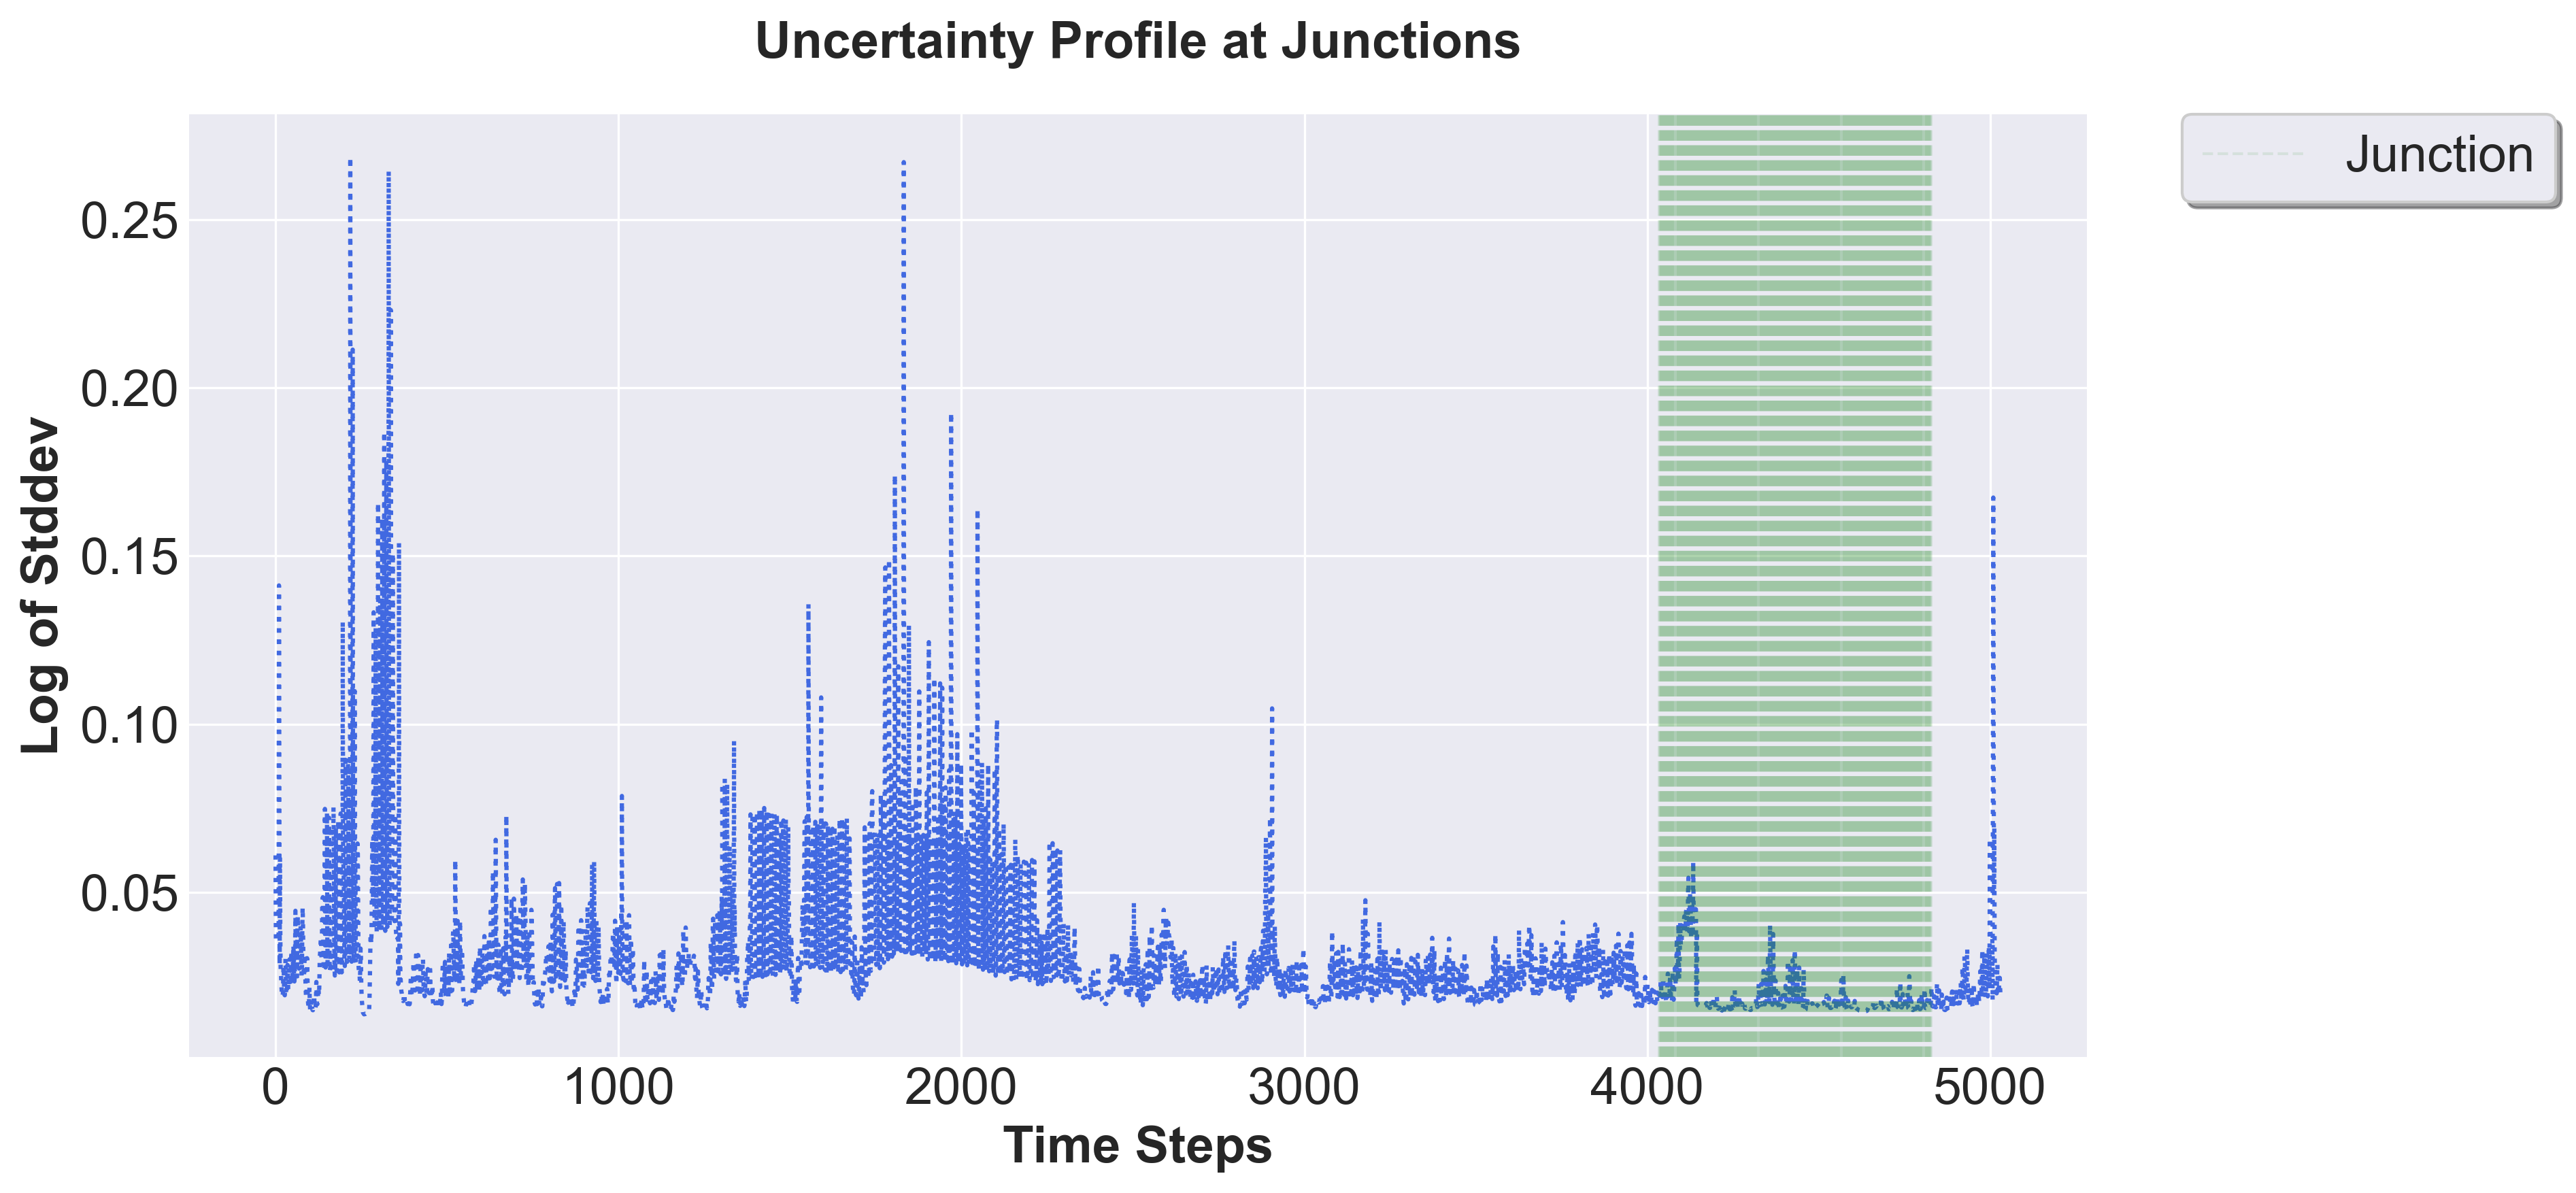

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# plt.rcParams['text.usetex'] = True
# Set the style
fontsize=18
plt.rcParams["font.size"]=fontsize
plt.rcParams['axes.labelsize'] = fontsize
plt.rcParams['axes.titlesize'] = fontsize
plt.style.use('seaborn-v0_8-darkgrid')
# sns.set_context("paper", font_scale=1.2)

# Create the figure with a specific size and DPI
plt.figure(figsize=(12, 6), dpi=300)

# Plot with enhanced styling
# Standard deviations (dotted lines)
plt.plot(np.array(log_stds), color='royalblue', linestyle=':',  
         linewidth=1.5)
# plt.plot(np.array(log_stds)[:,1], color='crimson', linestyle=':',
#          label='Throttle', linewidth=1.5)


# Add vertical lines for junctions and restarts
for k in junctions:
    plt.axvline(x=k, color='forestgreen', ls='--', alpha=0.1, linewidth=1,
                label='Junction' if k == junctions[0] else '')


# Customize the plot
plt.xlabel('Time Steps', fontsize=fontsize, fontweight='bold')
plt.ylabel('Log of Stddev', fontsize=fontsize, fontweight='bold')
plt.title('Uncertainty Profile at Junctions', fontsize=fontsize, fontweight='bold', pad=20)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
# Enhance the legend
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.,
          frameon=True, fancybox=True, shadow=True,fontsize=fontsize)

# Adjust layout to prevent legend cutoff
# plt.tight_layout()

# Save with high quality
plt.savefig("uncertainty_profile_at_junctions.pdf", dpi=300, bbox_inches='tight',
            format='pdf', facecolor='white', edgecolor='none')

# Optional: save also as PNG for quick viewing
# plt.savefig("uncertainty_profile_at_junctions.png", dpi=300, bbox_inches='tight',
            # format='png', facecolor='white', edgecolor='none')
plt.show()
plt.close()

In [ ]:
# data={
#     "GNM":"/home/robotlab/scratch/carla-rl/gnm_results.pkl",
#     "NoMaD":"/home/robotlab/scratch/carla-rl/nomad_results.pkl",
#     "ViNT":"/home/robotlab/scratch/carla-rl/vint_results.pkl"
# }

In [ ]:
# plots={}
# mean_distance_between_frames=0.129849 #m
# for l,v in data.items():
#     with open(v, 'rb') as handle:
#         dataset=pickle.load(handle)
#     data_keys=list(dataset.keys())
#     success_rate=[]
#     skip_frame=[]
#     for k  in data_keys:
#         if k != "experiment_results" and k != "SPLs":
#             # print(data_keys[k],k, k != "experiment_results" and k != "SPLs")
#             success_rate.append(np.mean(dataset[k]))
#             # print(k)
#             skip_frame.append(int(k))
#     # print(f"l = {l}",success_rate)
#     d={}
#     mean_distance_between_frames=dataset["experiment_results"]["mean_distance_per_step"]
#     # print(data_keys)
#     d[l]={
#         "x":np.array(skip_frame)*mean_distance_between_frames,
#         "y":success_rate,
#         "SPL":dataset["experiment_results"]["max_SPL"]
#     }
#     plots.update(d)

In [ ]:
# plots

In [ ]:
# import random
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from scipy.interpolate import make_smoothing_spline


# # x_range = np.arange(x_min, x_max, some_step)
# # plt.plot(x_range, cs(x_range), label='Cubic Spline')
# # plt.rcParams['text.usetex'] = True
# # Set the style
# plt.style.use('seaborn-v0_8-darkgrid')
# sns.set_context("paper", font_scale=1.2)

# # Create the figure with a specific size and DPI
# plt.figure(figsize=(12, 6), dpi=300)


# # Plot with enhanced styling
# # Standard deviations (dotted lines)
# ar=["crimson","royalblue","forestgreen"]
# for ix,(p,v) in enumerate(plots.items()):
#     x=v["x"]
#     y=v["y"]
#     cs = make_smoothing_spline(x,y)
#     # plt.plot(x,y, color='royalblue', alpha=0.6, 
#     #          label='NoMaD', linewidth=1.5)
#     plt.plot(x,cs(x), color=ar[ix], alpha=0.3, 
#             label=p, linewidth=1.5)
#     plt.axvline(x=x[np.argmax(y)], color=ar[ix], ls='--', alpha=0.5, linewidth=1.5,
#                 label='')
#     print(p,"Optimal Skip Frame",x[np.argmax(y)],"Max Success Rate",np.max(y),"Max SPL",v["SPL"])
# # plt.plot(np.array(log_stds)[:,1], color='crimson', linestyle=':', alpha=0.6, 
# #          label='Throttle', linewidth=1.5)

# # Add vertical lines for junctions and restarts
# # for k in junctions:
# #     plt.axvline(x=k, color='forestgreen', ls='--', alpha=0.5, linewidth=1.5,
# #                 label='Junction' if k == junctions[0] else '')


# # Customize the plot
# plt.xlabel('Mean Distance Between Nodes', fontsize=12, fontweight='bold')
# plt.ylabel('Mean Success Rate', fontsize=12, fontweight='bold')
# # plt.title('Uncertainty Profile at Junctions', fontsize=14, fontweight='bold', pad=20)

# # Enhance the legend
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.,
#           frameon=True, fancybox=True, shadow=True)

# # Adjust layout to prevent legend cutoff
# # plt.tight_layout()

# # Save with high quality
# plt.savefig("success_rate.pdf", dpi=300, bbox_inches='tight',
#             format='pdf', facecolor='white', edgecolor='none')

# # Optional: save also as PNG for quick viewing
# # plt.savefig("uncertainty_profile_at_junctions.png", dpi=300, bbox_inches='tight',
#             # format='png', facecolor='white', edgecolor='none')
# plt.show()
# plt.close()

In [1]:
import glob
base_path="/home/robotlab/scratch/carla-rl/results"


In [9]:
import os
import pickle
import numpy as np
models=os.listdir(base_path)
results={}
for model in models:
    results[model]={}
    difficulties=os.listdir(os.path.join(base_path,model))
    
    for difficulty in difficulties:
        trajectory_success=[]
        trajectory_spls=[]
        nodes=None
        mean_nodes=None
        mean_distance_before_interventions=[]
        total_distance_to_goal=[]
        for trajectory in glob.glob(f"{os.path.join(os.path.join(base_path,model,difficulty))}/*.pkl"):
          with open(trajectory, 'rb') as handle:
                dataset=pickle.load(handle)
                # print(dataset["experiment_results"],trajectory)
                success_rate=dataset["experiment_results"]["success_rate"]
                max_spl=dataset["experiment_results"]["max_SPL"]
                nodes=dataset["experiment_results"].get("nodes",0)
                mean_nodes=dataset.get("mean_nodes",0)
                trajectory_success.append(success_rate)
                mean_distance_before_interventions.extend(dataset["experiment_results"]["distance_completed"])
                total_distance_to_goal.append(dataset["experiment_results"]["shortest_distance_along_road"])
                trajectory_spls.append(max_spl)
        cleaned_distances = np.maximum(mean_distance_before_interventions, 0)


        results[model][difficulty]={
            "trajectorys":trajectory_success.__len__(),
            "mean_success_rate":np.mean(trajectory_success),
            "std_success_rate":np.mean(trajectory_success),
            "mean_spl":np.mean(trajectory_spls),
            "node":nodes,
            "mean_nodes":mean_nodes,
            "mean_distance_before_interventions":np.mean(cleaned_distances),
            "mean_distance_to_goal":np.mean(total_distance_to_goal)

        }
        nodes=None

print(results)
    # print(difficulty)

{'PixelBCLearner': {'easy': {'trajectorys': 5, 'mean_success_rate': np.float64(0.2), 'std_success_rate': np.float64(0.2), 'mean_spl': np.float64(0.0), 'node': 0, 'mean_nodes': 0, 'mean_distance_before_interventions': np.float64(90.13833431744781), 'mean_distance_to_goal': np.float64(85.0239798884256)}, 'random': {'trajectorys': 1, 'mean_success_rate': np.float64(0.0), 'std_success_rate': np.float64(0.0), 'mean_spl': np.float64(0.0), 'node': 0, 'mean_nodes': 4, 'mean_distance_before_interventions': np.float64(0.0), 'mean_distance_to_goal': np.float64(266.43374861286713)}, 'hard': {'trajectorys': 5, 'mean_success_rate': np.float64(0.0), 'std_success_rate': np.float64(0.0), 'mean_spl': np.float64(0.0), 'node': 0, 'mean_nodes': 0, 'mean_distance_before_interventions': np.float64(163.96173421950544), 'mean_distance_to_goal': np.float64(219.0302222351892)}, 'trajectories': {'trajectorys': 5, 'mean_success_rate': np.float64(0.0), 'std_success_rate': np.float64(0.0), 'mean_spl': np.float64(0.0

In [ ]:
base="/home/robotlab/scratch/carla-rl/evaluation_trajectory"
node_size={}
for difficulty in os.listdir(base):
    node_size[difficulty]=0
    path=base+"/"+difficulty
    nodes_lengths=[]
    for trajectory in os.listdir(path):
        path = path+"/"+trajectory
        nodes_lengths.append(len(list(glob.glob(path+"/*"))))
        # print(len(glob.glob(path+"/*")))
    node_size[difficulty]=np.mean(nodes_lengths)
 
    # print()
print(node_size)
